In [6]:
import numpy as np
import pandas as pd
%matplotlib inline

df = pd.read_csv('./monthly_milk_production.csv', encoding='utf8')
title = "Monthly milk production: pounds per cow. Jan '62 - Dec '75"

In [7]:
df.dtypes

Date          object
Production     int64
dtype: object

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date          datetime64[ns]
Production             int64
dtype: object

In [9]:
df = df.set_index('Date')

In [10]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


<Axes: xlabel='Date'>

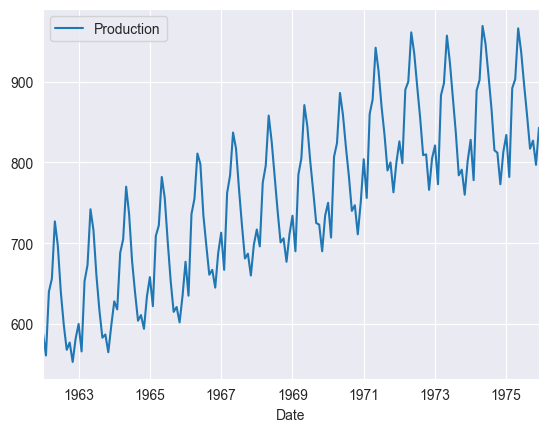

In [11]:
df.plot()

In [12]:
df['Month'] = df.index.month

In [13]:
df['Month'] = df.index.strftime('%B')

<Axes: title={'center': 'Production'}, xlabel='[Month]'>

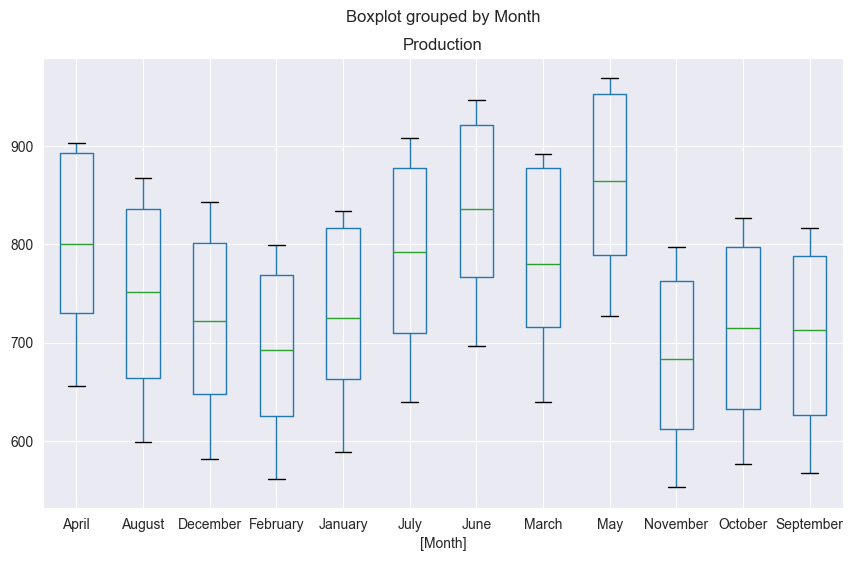

In [14]:
df[['Production', 'Month']].boxplot(by='Month', grid=True, figsize=(10,6))

In [16]:
starbucks = pd.read_csv('./starbucks.csv', index_col='Date', parse_dates=True)

In [17]:
starbucks.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2018-12-17', '2018-12-18', '2018-12-19', '2018-12-20',
               '2018-12-21', '2018-12-24', '2018-12-26', '2018-12-27',
               '2018-12-28', '2018-12-31'],
              dtype='datetime64[ns]', name='Date', length=1006, freq=None)

<Axes: xlabel='Date'>

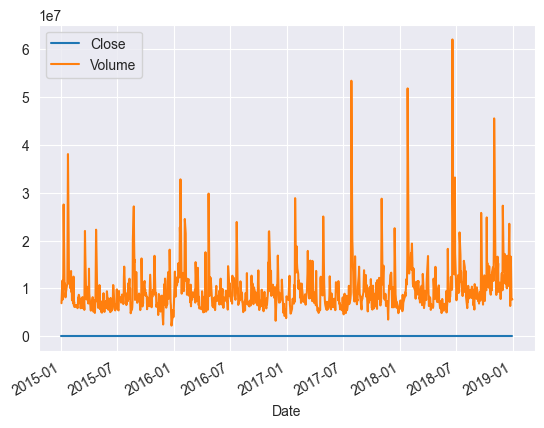

In [18]:
starbucks.plot()

This isn't very helpful due to the difference in y-values, so I am split them up.

[Text(0.5, 0, 'Closing Date'), Text(0, 0.5, 'Closing Price (USD)')]

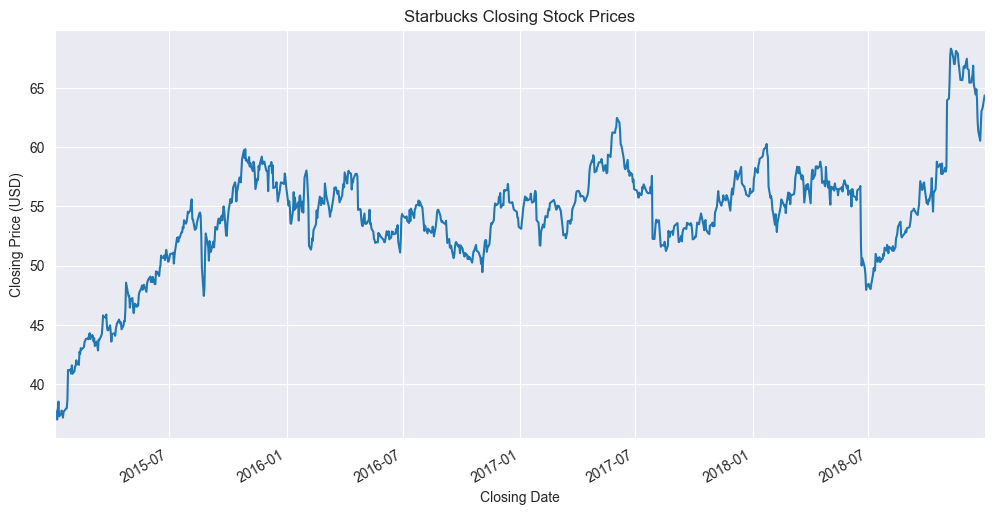

In [19]:
title='Starbucks Closing Stock Prices'
ylabel='Closing Price (USD)'
xlabel='Closing Date'

ax = starbucks['Close'].plot(figsize=(12,6),title=title)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

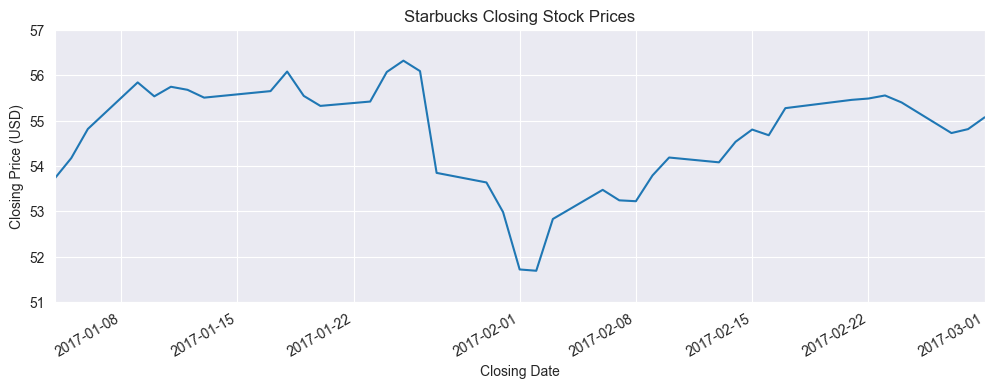

In [20]:
#dates separated by commas
title='Starbucks Closing Stock Prices'
ylabel='Closing Price (USD)'
xlabel='Closing Date'

ax = starbucks['Close'].plot(xlim=['2017-01-04','2017-03-01'],ylim=[51,57],figsize=(12,4),title=title)
ax.set(xlabel=xlabel, ylabel=ylabel);

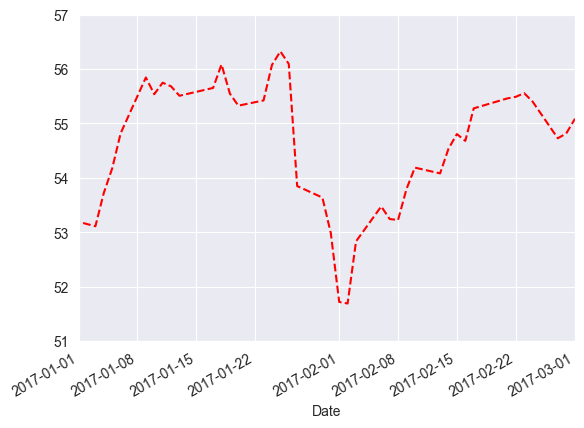

In [21]:
starbucks['Close'].plot(xlim=['2017-01-01','2017-03-01'],ylim=[51,57],ls='--',c='r');

In [22]:

from matplotlib import dates

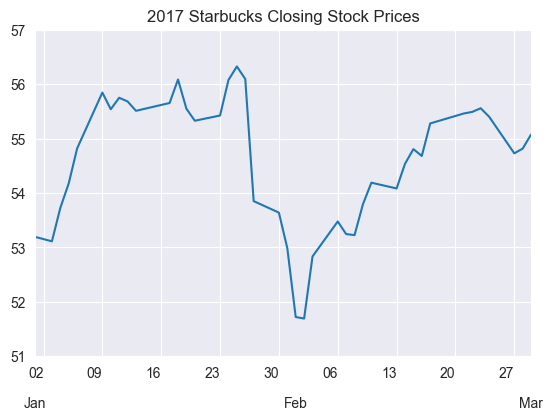

In [23]:

ax = starbucks['Close'].plot(xlim=['2017-01-01','2017-03-01'],ylim=[51,57],rot=0,title='2017 Starbucks Closing Stock Prices')
ax.set(xlabel='')

ax.xaxis.set_major_locator(dates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(dates.DateFormatter('%d'))

ax.xaxis.set_minor_locator(dates.MonthLocator())
ax.xaxis.set_minor_formatter(dates.DateFormatter('\n\n%b'))

ax.yaxis.grid(True)
ax.xaxis.grid(True)

In [25]:
df2 = pd.read_csv('./UMTMVS.csv', parse_dates=True)

In [26]:
df2 = df2.set_index('DATE')

In [27]:
df2.index = pd.to_datetime(df2.index)

<Axes: xlabel='DATE'>

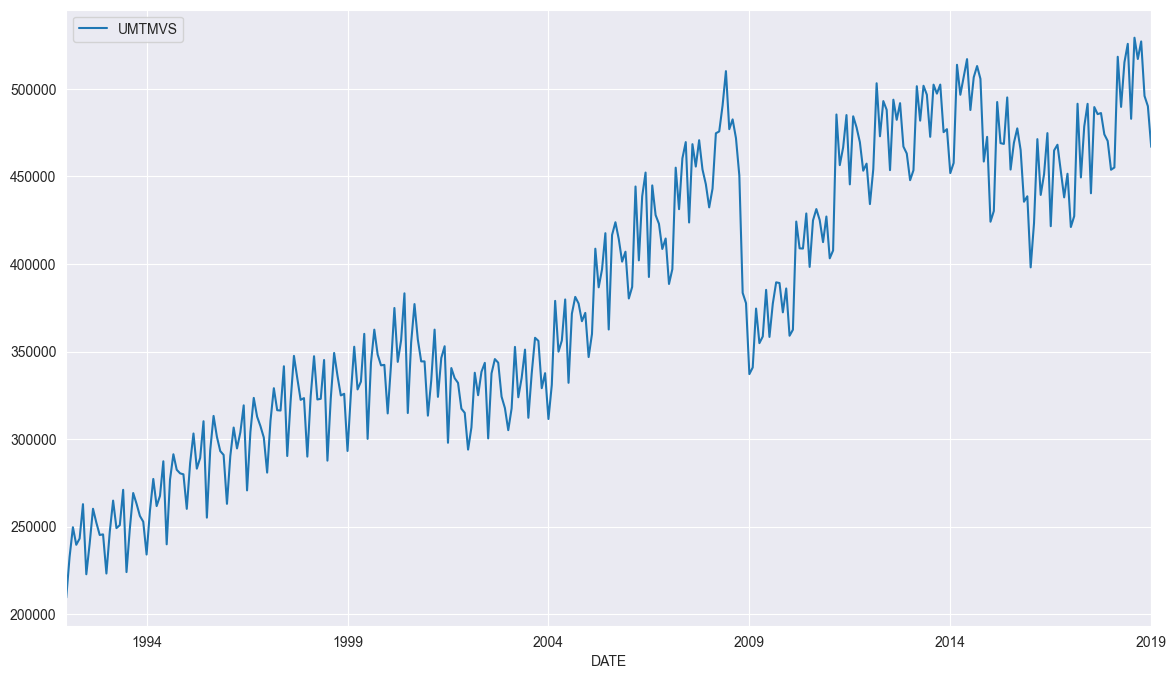

In [28]:
df2.plot(figsize=(14,8))

In [29]:
# to get the percent increase in value from Jan 2009 to Jan 2019
100 * (df2.loc['2019-01-01'] - df2.loc['2009-01-01']) / df2.loc['2009-01-01']

UMTMVS    38.472149
dtype: float64

In [30]:
# six months with highest values
df2.sort_values(by='UMTMVS',ascending=False).head(5)

,UMTMVS
DATE,
2018-08-01,529157.0
2018-10-01,527031.0
2018-06-01,525660.0
2018-03-01,518285.0
2018-09-01,516992.0


/var/folders/gt/l11hthzx21ng8gl1ybn_v9bc0000gn/T/ipykernel_86706/2801575642.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df2.resample('Y').mean().plot.bar(figsize=(15,8))


<Axes: xlabel='DATE'>

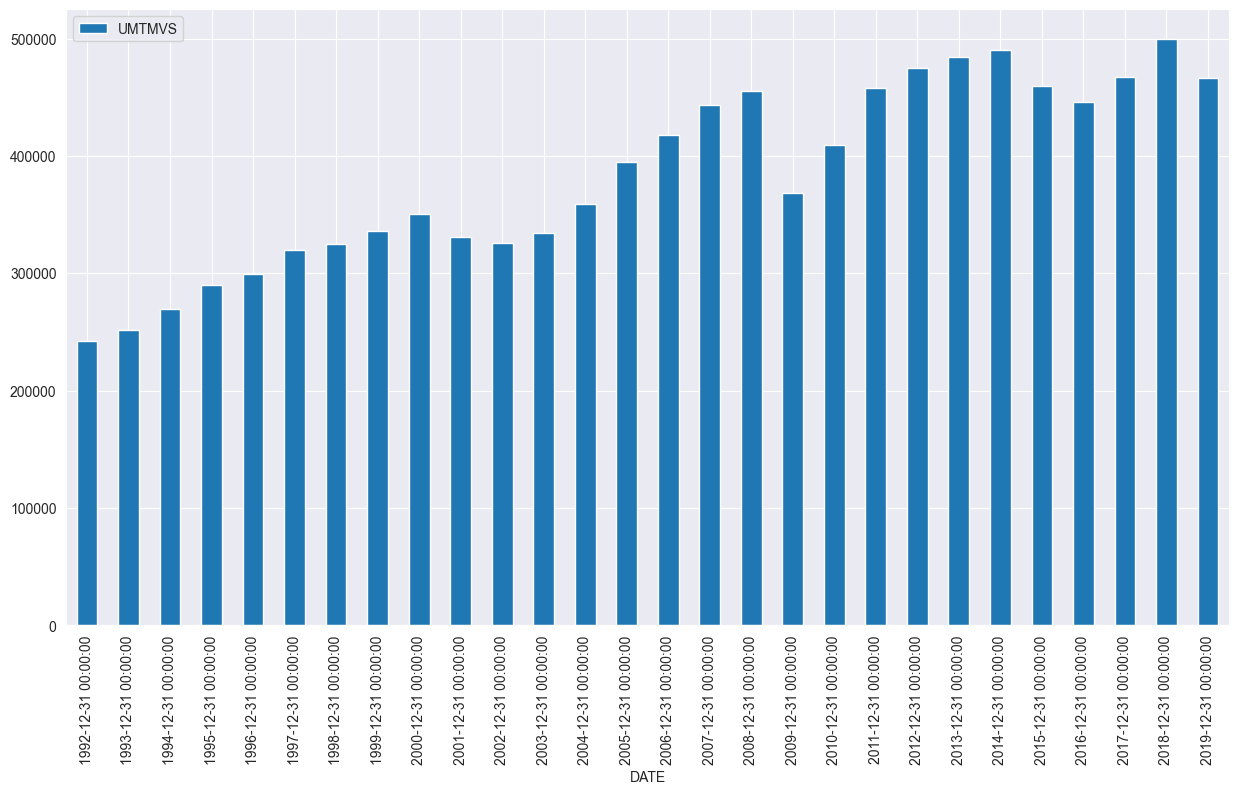

In [31]:
df2.resample('Y').mean().plot.bar(figsize=(15,8))

The year had the biggest increase in mean value from the previous year's mean value

In [32]:
yearly_data = df2.resample('Y').mean()
yearly_data_shift = yearly_data.shift(1)

/var/folders/gt/l11hthzx21ng8gl1ybn_v9bc0000gn/T/ipykernel_86706/972651099.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_data = df2.resample('Y').mean()


In [33]:
change = yearly_data - yearly_data_shift

In [34]:
change['UMTMVS'].idxmax()

Timestamp('2011-12-31 00:00:00')

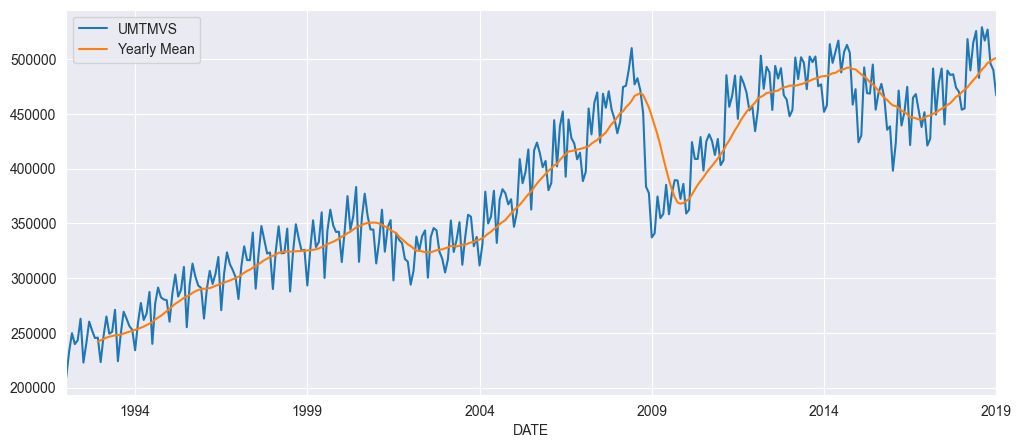

In [35]:
df2['Yearly Mean'] = df2['UMTMVS'].rolling(window=12).mean()
df2[['UMTMVS','Yearly Mean']].plot(figsize=(12,5)).autoscale(axis='x',tight=True)

general forecasting models

In [36]:
airline = pd.read_csv('./airline_passengers.csv', index_col='Month', parse_dates=True)

In [37]:
airline.tail()
airline.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [38]:
airline.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Thousands of Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [39]:
train = airline.iloc[:109]
test = airline.iloc[108:]

In [41]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [42]:
fit_model = ExponentialSmoothing(train['Thousands of Passengers'], trend='multiplicative', seasonal='multiplicative', seasonal_periods=12).fit()

/Users/fatimarahimi/PycharmProjects/first.py/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [43]:
test_pred = fit_model.forecast(36)

In [44]:
test_pred

1958-02-01    339.144216
1958-03-01    399.282850
1958-04-01    394.234338
1958-05-01    402.545229
1958-06-01    473.127861
1958-07-01    521.794513
1958-08-01    514.512758
1958-09-01    446.216729
1958-10-01    385.431044
1958-11-01    339.644981
1958-12-01    381.455651
1959-01-01    401.210048
1959-02-01    387.159253
1959-03-01    455.812137
1959-04-01    450.048871
1959-05-01    459.536394
1959-06-01    540.111906
1959-07-01    595.668638
1959-08-01    587.355954
1959-09-01    509.390775
1959-10-01    439.999232
1959-11-01    387.730915
1959-12-01    435.461015
1960-01-01    458.012181
1960-02-01    441.972116
1960-03-01    520.344673
1960-04-01    513.765460
1960-05-01    524.596199
1960-06-01    616.579354
1960-07-01    680.001645
1960-08-01    670.512075
1960-09-01    581.508817
1960-10-01    502.293024
1960-11-01    442.624712
1960-12-01    497.112300
1961-01-01    522.856193
Freq: MS, dtype: float64

Given that we have seasonality in data, the pred is not perfect but pretty good so far

<Axes: xlabel='Month'>

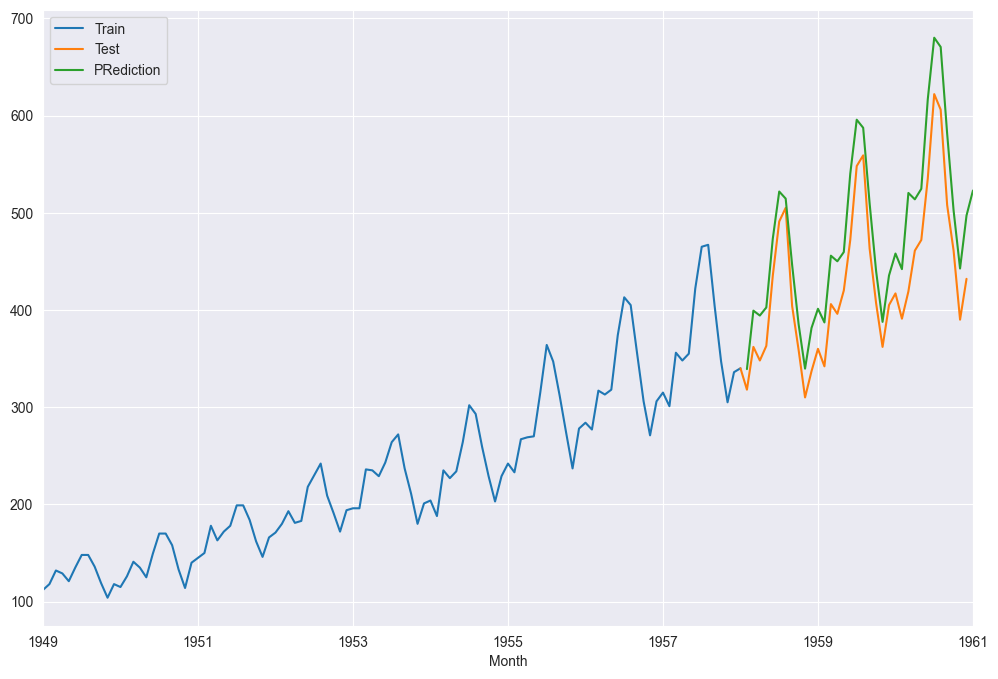

In [45]:
train['Thousands of Passengers'].plot(legend=True, label='Train', figsize=(12,8))
test['Thousands of Passengers'].plot(legend=True, label='Test', figsize=(12,8))
test_pred.plot(legend= True, label= 'PRediction', figsize=(12,8))

<Axes: xlabel='Month'>

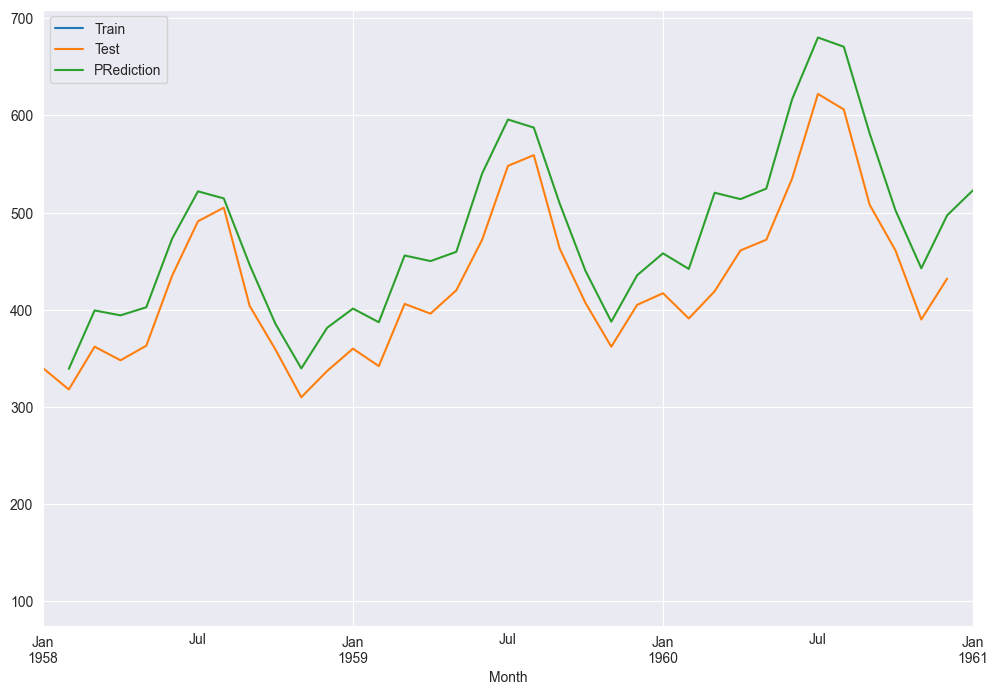

In [46]:
train['Thousands of Passengers'].plot(legend=True, label='Train', figsize=(12,8))
test['Thousands of Passengers'].plot(legend=True, label='Test', figsize=(12,8))
test_pred.plot(legend= True, label= 'PRediction', figsize=(12,8), xlim =['1958-01-01', '1961-01-01'])

Let's do a evaluation of this with metrics designed for continuous values!
##### Mean Absolute Error (MAE) : won't alert us if we have a few error points
##### Mean Squared Error (MSE) : Larger are noted more than with MAE, can report the few errors that are off. Problem: the units are squared; makes it hard to interpret.
##### Root Mean Squared Error (RMSE) : The root will take care of the units back in the original form

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [48]:
test.describe()

,Thousands of Passengers
count,36.000000
mean,428.500000
std,79.329152
min,310.000000
25%,362.000000
50%,412.000000
75%,472.000000
max,622.000000


In [85]:
mean_squared_error(test, test_pred)

5614.249320273678

In [49]:
import numpy as np
x = np.sqrt(mean_squared_error(test, test_pred))
print(x)

74.92671322854953


In [50]:
mean_absolute_error(test, test_pred)

63.03014353330715

In [51]:
final_model = ExponentialSmoothing(airline['Thousands of Passengers'], trend='multiplicative', seasonal='multiplicative', seasonal_periods=12).fit()

/Users/fatimarahimi/PycharmProjects/first.py/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [52]:
forecast_pred = final_model.forecast(36)

pretty good, we still hae the seasonality effect in our future forecast

<Axes: xlabel='Month'>

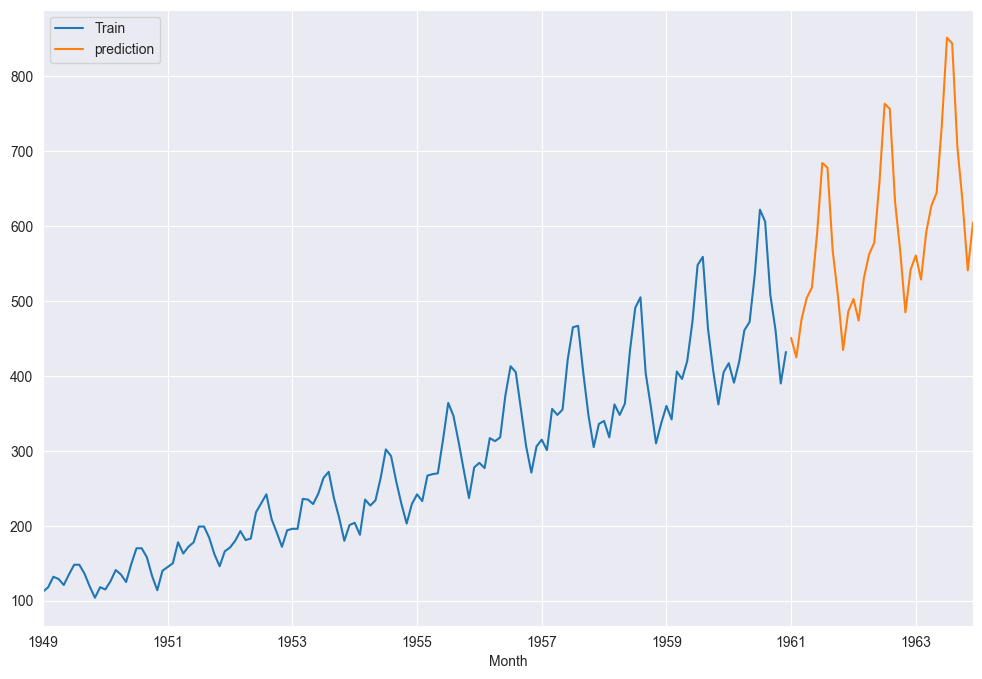

In [53]:
airline['Thousands of Passengers'].plot(legend=True, label='Train', figsize=(12,8))
forecast_pred.plot(legend=True, label='prediction', figsize=(12,8))

#### Stationarity : time series are stationary if they dont have seasonality or trends. fluctuation in data is based on outside forces
#### Differencing :

In [54]:
sample = pd.read_csv('./samples.csv', parse_dates=True, index_col=0)

In [55]:
sample.head()

,a,b,c,d
1950-01-01,36,27,0,67
1950-02-01,58,22,3,31
1950-03-01,61,17,5,67
1950-04-01,37,15,8,47
1950-05-01,66,13,8,62


Stationary data

<Axes: >

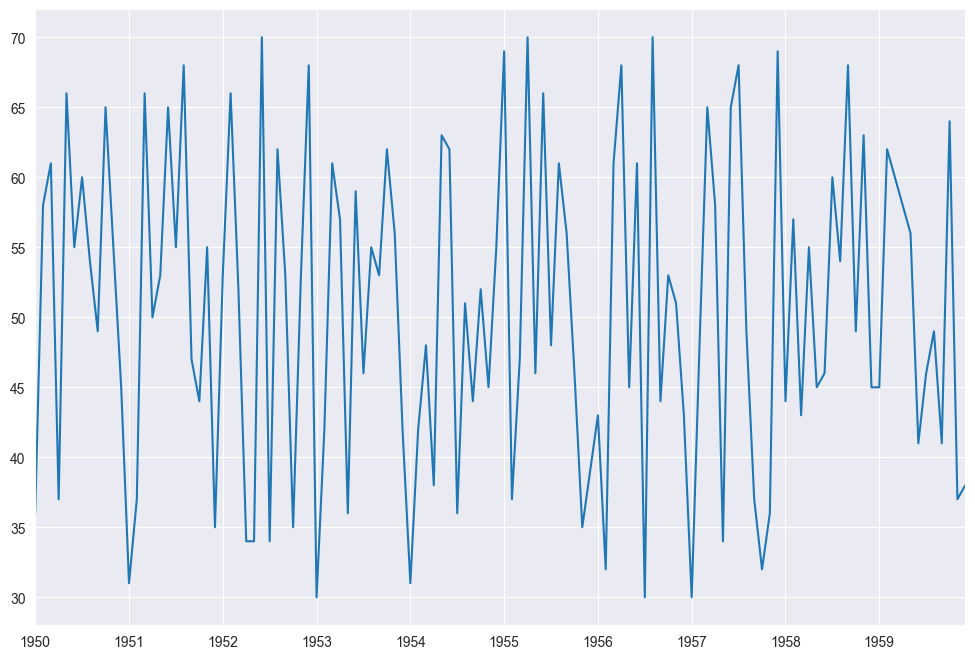

In [56]:
sample['a'].plot(figsize=(12,8))

non stationary data

<Axes: >

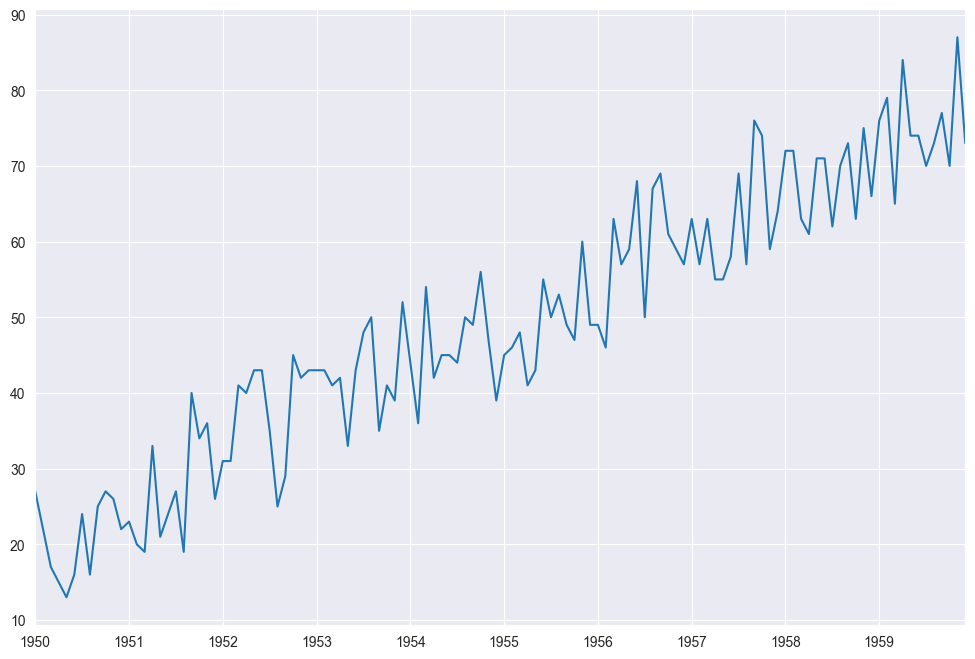

In [57]:
sample['b'].plot(figsize=(12,8))

In [58]:
from statsmodels.tsa.statespace.tools import diff

In [59]:
#the first order difference
sample['b'] - sample['b'].shift()

1950-01-01     NaN
1950-02-01    -5.0
1950-03-01    -5.0
1950-04-01    -2.0
1950-05-01    -2.0
              ... 
1959-08-01     3.0
1959-09-01     4.0
1959-10-01    -7.0
1959-11-01    17.0
1959-12-01   -14.0
Name: b, Length: 120, dtype: float64

<Axes: >

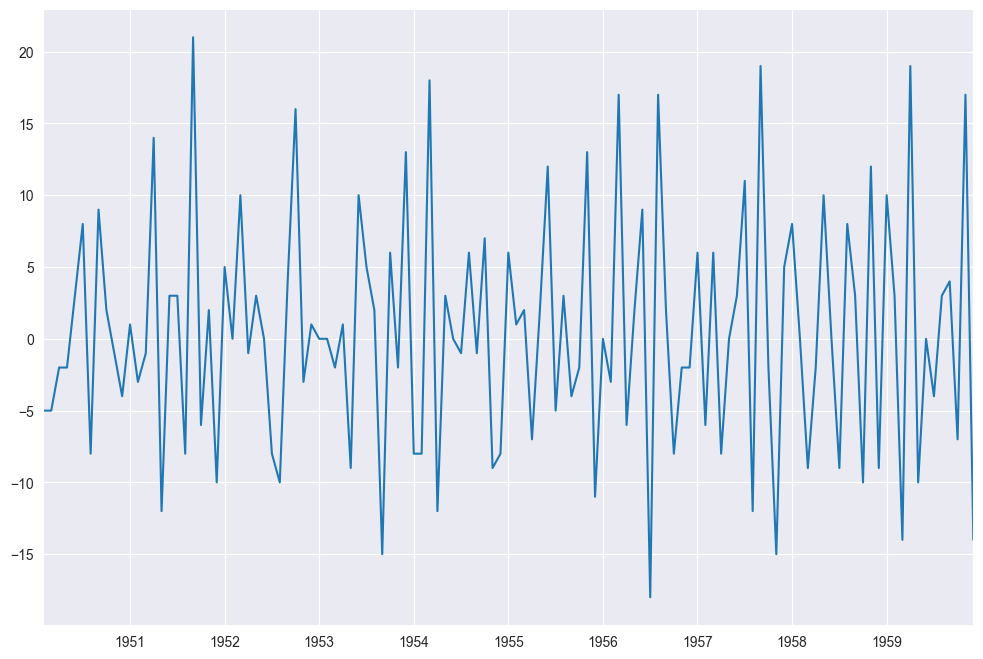

In [60]:
diff(sample['b'], k_diff=1).plot(figsize=(12,8))

#### AutoCorrelation Function Plot (ACF): correlation of the series with itself, lagged by certain number of time units. how correlated are today's sales with yesterday's sales.
Common patterns: Gradual decline / sharp drop offs
#### Partial AutoCorrelation Function Plot (PACF): residual; error not explained by linear model. residuals on lagged days and keep repeating them. direct relation between observation and lag.

#### How it relates to ARIMA model?

In [61]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import  acovf, acf, pacf, pacf_yw, pacf_ols

In [62]:
data = pd.read_csv('./airline_passengers.csv', index_col='Month', parse_dates=True)

In [63]:
data2 = pd.read_csv('./DailyTotalFemaleBirths.csv', index_col='Date', parse_dates=True)
data2.index.freq='D'

In [64]:
data.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [65]:
data2.head()

,Births
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


In [66]:
data_f = pd.DataFrame({'a': [13, 5,11,12,9]})

In [67]:
acf(data_f['a'])

array([ 1.   , -0.5  , -0.2  ,  0.275, -0.075])

In [68]:
pacf_yw(data_f['a'], nlags=4, method='mle')

array([ 1.        , -0.5       , -0.6       , -0.38541667, -0.40563273])

In [69]:
pacf_ols(data_f['a'], nlags=2)

array([ 1.        , -0.49677419, -0.43181818])

In [70]:
from pandas.plotting import lag_plot

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

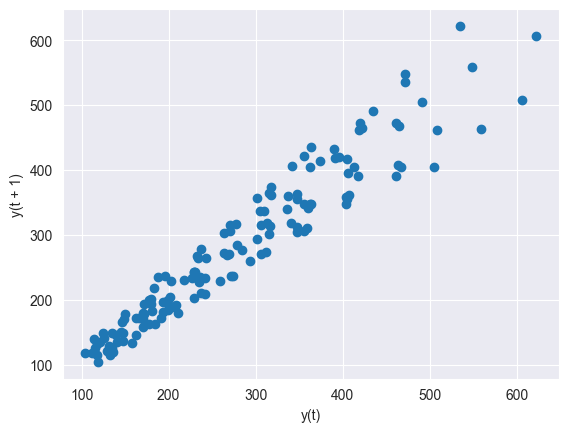

In [71]:
lag_plot(data['Thousands of Passengers'])

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

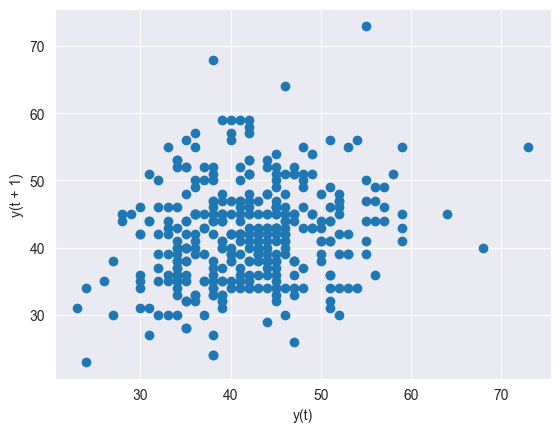

In [72]:
lag_plot(data2['Births'])

In [73]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Axes: xlabel='Month'>

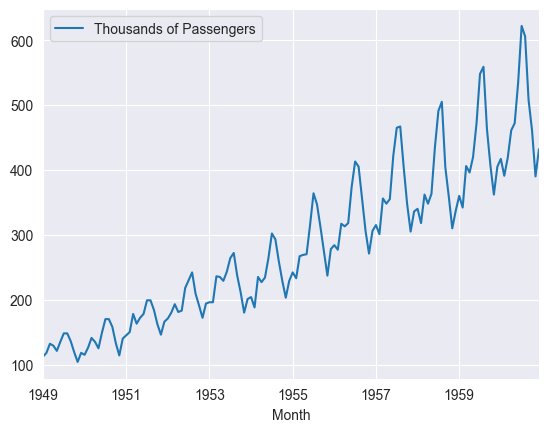

In [74]:
data.plot()

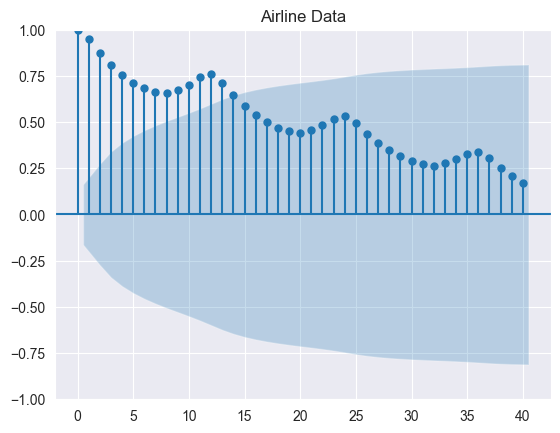

In [75]:
plot_acf(data, lags=40, title='Airline Data');

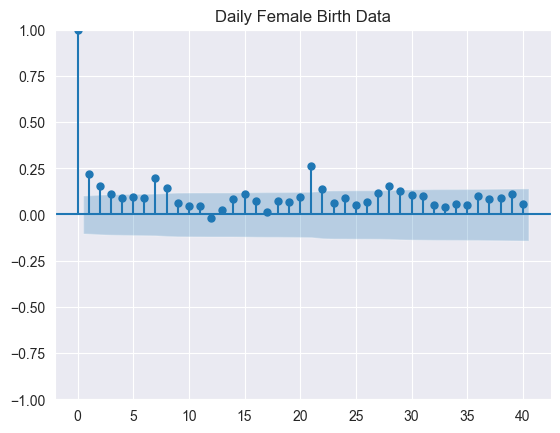

In [76]:
plot_acf(data2, lags=40, title='Daily Female Birth Data');

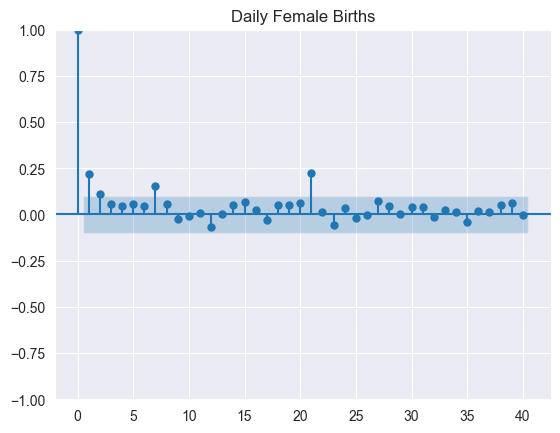

In [77]:
plot_pacf(data2, lags=40, title='Daily Female Births');

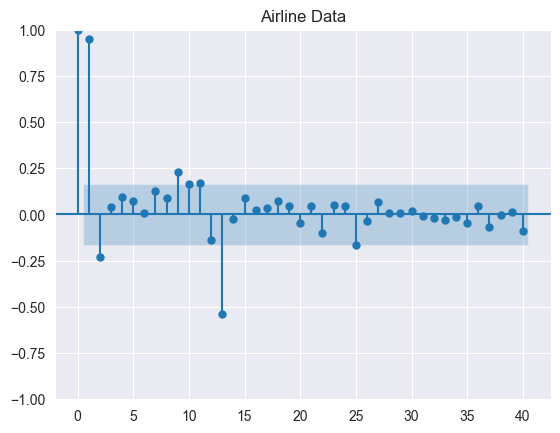

In [78]:
plot_pacf(data, lags=40, title='Airline Data');

# ARIMA Models (Auto regressive integrated moving average model):
Performs well if the only factor of change is time. It does a future point forecast so now distribution.
to make a non-stationary dataset stationary.
We use stocks prices log returns because it makes it approx stationary. log returns has a constant mean and variance.
Covariance should also not be a function of time.
Augmented Dickey Fuller test for stationarity.
log return is through differencing.




# Auto regression
The order is based on the lag terms you try to predict up on. The more lagged steps will give you better result because you are using more historical data. The stats lib can choose the best order for us.

In [201]:
from statsmodels.tsa.ar_model import AutoReg, ARResults, ar_select_order

In [202]:
df = pd.read_csv('./uspopulation.csv', index_col='DATE', parse_dates=True)

In [203]:
df.index.freq = 'MS'

In [204]:
df.head()

,PopEst
DATE,
2011-01-01,311037
2011-02-01,311189
2011-03-01,311351
2011-04-01,311522
2011-05-01,311699


<Axes: xlabel='DATE'>

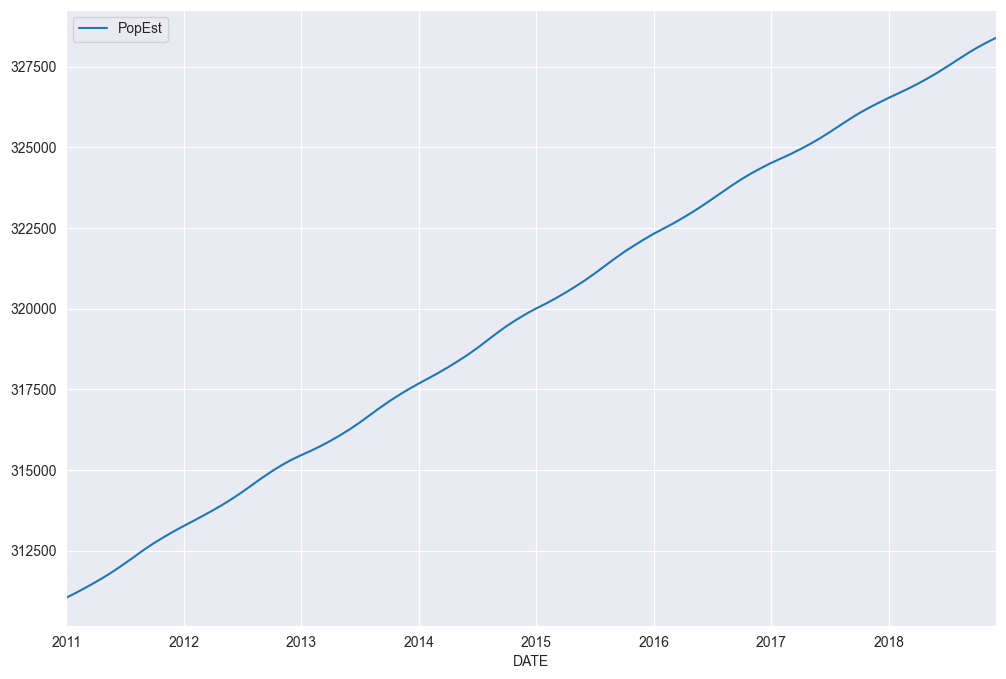

In [205]:
df.plot(figsize=(12,8))

In [206]:
len(df)

96

In [207]:
train = df.iloc[:84]
test = df.iloc[84:]

start = len(train)
end = len(train) + len(test) - 1
print(start, end)

84 95


In [208]:
import warnings
warnings.filterwarnings('ignore')

<Axes: xlabel='DATE'>

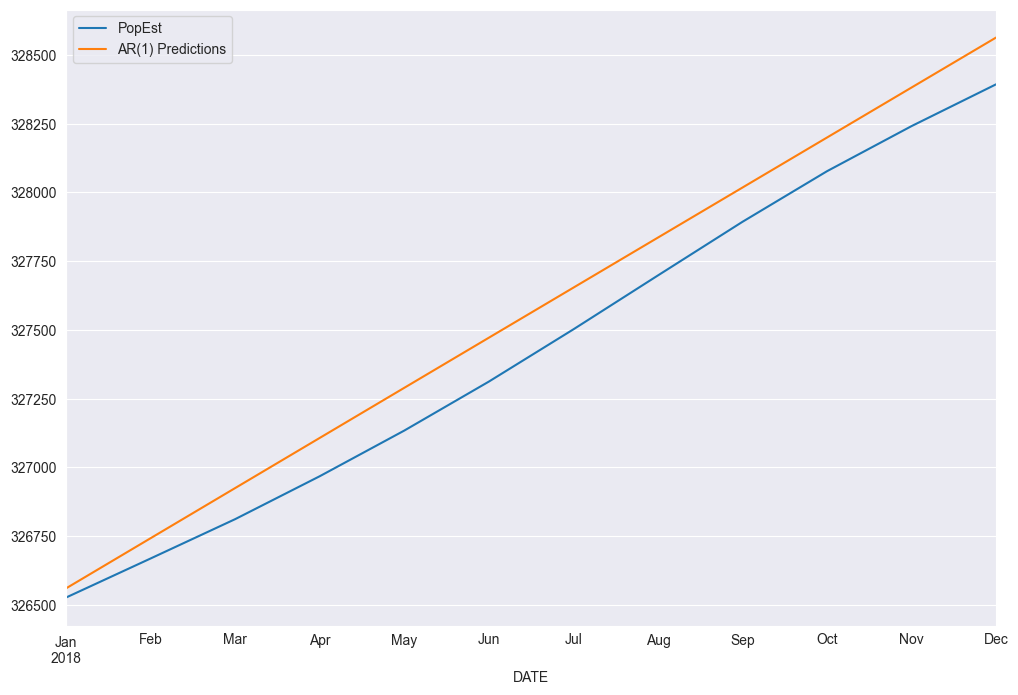

In [215]:
model = AutoReg(train['PopEst'], lags=1)
ARfit = model.fit()

ARfit.params
ARfit.summary()

pred1= ARfit.predict(start=start, end=end)
pred1 = pred1.rename('AR(1) Predictions')

test.plot(figsize=(12,8), legend=True)
pred1.plot(figsize=(12,8), legend=True)

<Axes: xlabel='DATE'>

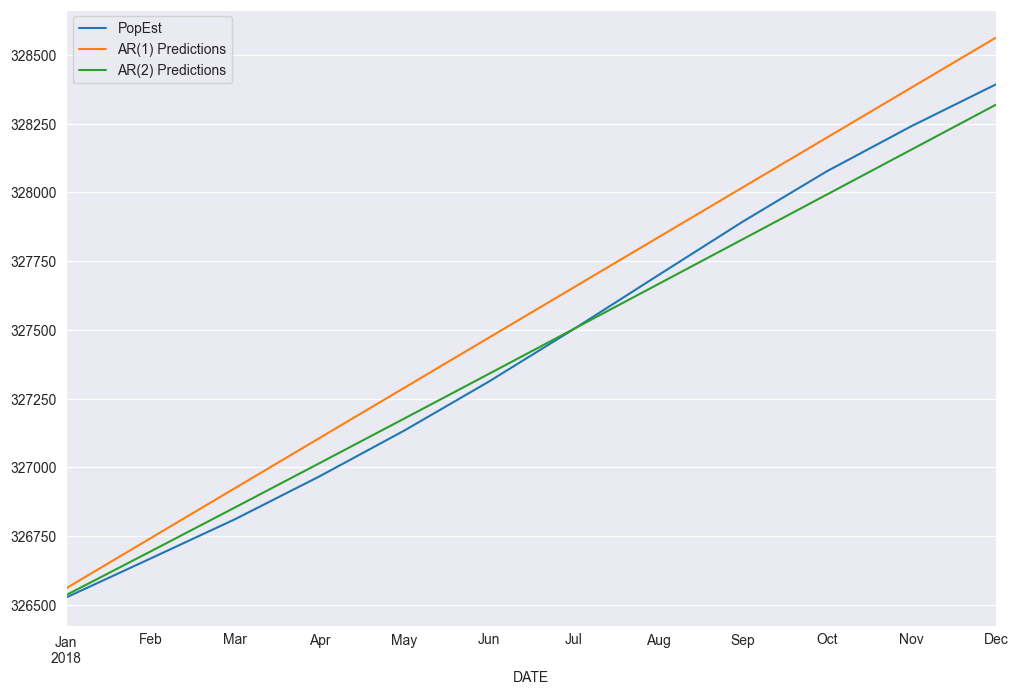

In [216]:
model2 = AutoReg(train['PopEst'], lags=2)
AR2fit = model2.fit()
AR2fit.summary()

pred2= AR2fit.predict(start=start, end=end)
pred2 = pred2.rename('AR(2) Predictions')

test.plot(figsize=(12,8), legend=True)
pred1.plot(figsize=(12,8), legend=True)
pred2.plot(figsize=(12,8), legend=True)

<Axes: xlabel='DATE'>

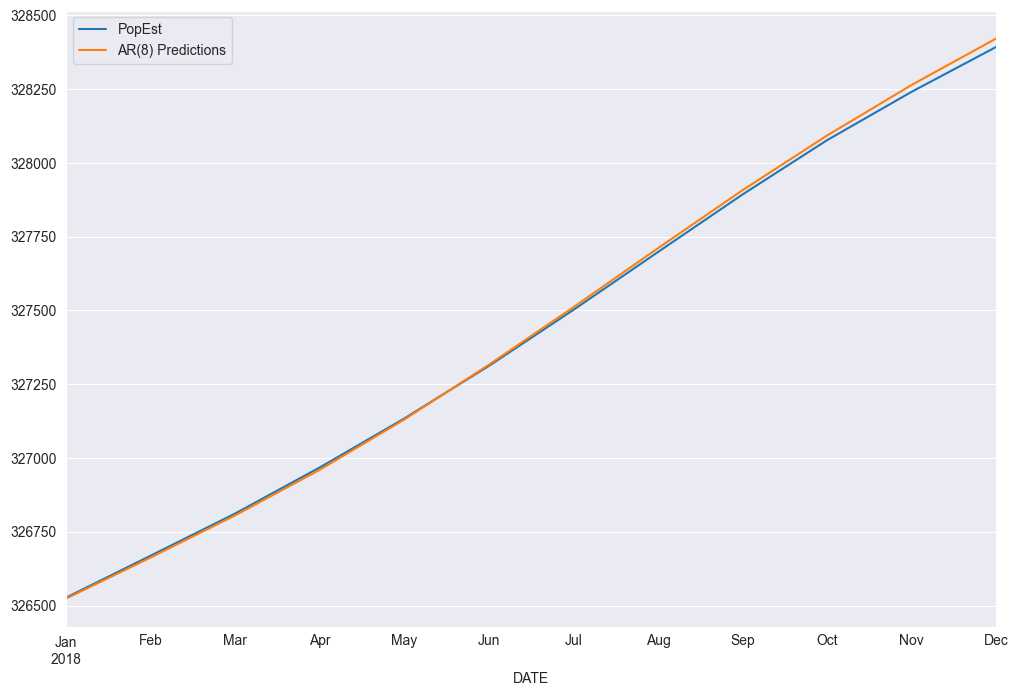

In [220]:
sel = ar_select_order(train['PopEst'], maxlag=10, ic='hqic')
model3 = AutoReg(train['PopEst'], lags=sel.ar_lags)
AR8fit = model3.fit()
AR8fit.summary()

pred8= AR8fit.predict(start=start, end=end)
pred8 = pred8.rename('AR(8) Predictions')

test.plot(figsize=(12,8), legend=True)
pred8.plot(figsize=(12,8), legend=True)

In [221]:
from sklearn.metrics import mean_squared_error

In [222]:
labels = ['AR1', 'AR2', 'AR8']
preds = [pred1, pred2, pred8]

for i in range(3):
    error = mean_squared_error(test['PopEst'], preds[i])
    print(f'{labels[i]} MSE: {error}')

AR1 MSE: 17449.714233344614
AR2 MSE: 2713.2585544971494
AR8 MSE: 186.97265234412137


In [228]:
# forecasting part
sel2 = ar_select_order(train['PopEst'], maxlag=10, ic='hqic')
model4 = AutoReg(df['PopEst'], lags=sel2.ar_lags )
ARfit4 = model4.fit()

forecasted_values = ARfit4.predict(start=len(df), end=len(df)+ 12).rename('Forecasted Values')


In [229]:
forecasted_values

2019-01-01    328537.134657
2019-02-01    328675.917687
2019-03-01    328818.863484
2019-04-01    328973.057109
2019-05-01    329142.516110
2019-06-01    329325.479759
2019-07-01    329516.233840
2019-08-01    329709.938410
2019-09-01    329899.389649
2019-10-01    330077.704896
2019-11-01    330242.358928
2019-12-01    330394.543614
2020-01-01    330538.846103
Freq: MS, Name: Forecasted Values, dtype: float64

<Axes: xlabel='DATE'>

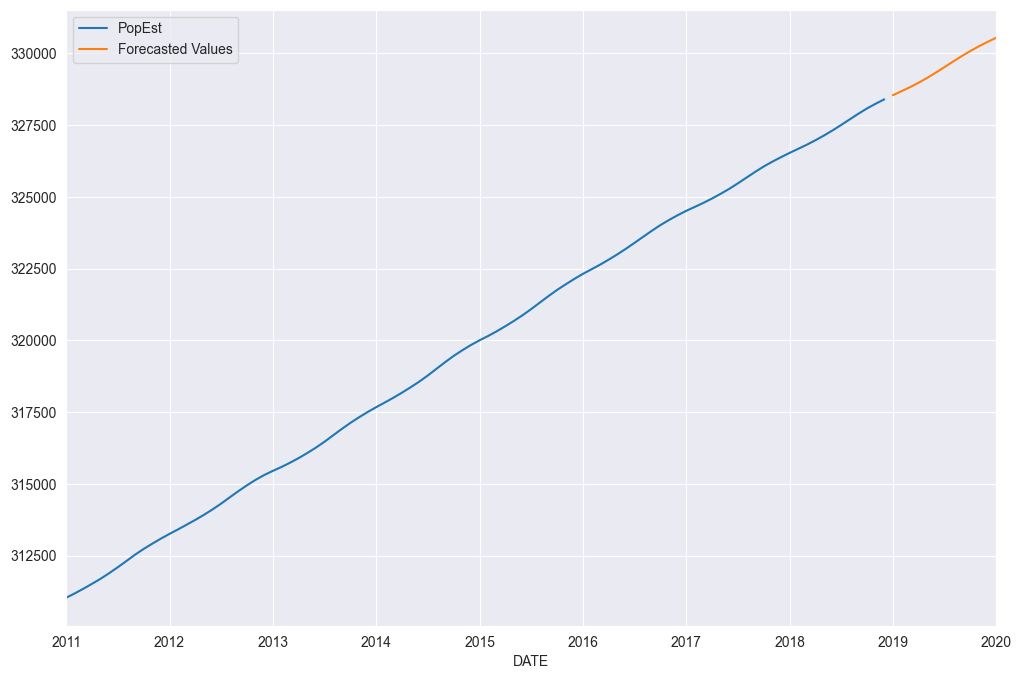

In [230]:
df['PopEst'].plot(figsize=(12,8), legend=True)
forecasted_values.plot(figsize=(12,8), legend=True)